# S02 — Estimación del tiempo de respuesta en ejercicios (Regresión)

## Objetivo

Construir un modelo de regresión que estime el `time_spent_seconds` (tiempo, en segundos,
que un estudiante tarda en resolver un ejercicio) a partir de características del intento
(dificultad, calidad de conectividad, tipo de dispositivo, hora del día, etc.). Este modelo
sirve como insumo para funcionalidades futuras de la plataforma Tutunaku, como estimar
tiempos restantes de una sesión de práctica o detectar intentos anómalamente lentos/rápidos.

Este notebook corresponde al escenario **S02** del proyecto integrador (capa de Machine
Learning sobre la app educativa Tutunaku).


## Resumen de la ETL previa

Los datos ya fueron generados por el simulador (`simulation/generate_dataset.py`, semilla 2026)
y procesados por el ETL del warehouse (`database/warehouse/build_warehouse.py`). Ese proceso
ya se ejecutó de forma independiente y produjo, entre otros artefactos:

- `data/raw/exercise_attempts.csv`: datos crudos simulados de intentos de ejercicio.
- `data/processed/exercise_attempts.csv`: tabla limpia con *feature engineering* aplicado
  (extracción de `hour_of_day` / `day_of_week` desde el timestamp, bandera de outliers
  `time_spent_outlier_flag`, y la columna `log1p_time_spent_seconds` ya calculada).
- `data/training/`, `data/validation/`, `data/test/`: particiones 70/15/15 ya generadas por
  la ETL (no se vuelven a re-particionar aquí, simplemente se cargan).
- `data/inference/exercise_attempts_inference_sample.csv`: una muestra pequeña reservada para
  demostrar predicciones fuera de línea con el modelo ya entrenado y serializado.

En este notebook **no se repite** ese trabajo: se cargan directamente los CSV ya
particionados y se reutiliza la columna `log1p_time_spent_seconds` (transformación
`log1p` del target) que la ETL ya dejó calculada, tal como pide el enunciado.


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

REPO_ROOT = Path("../..").resolve()
DATA_DIR = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models" / "serialized"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)


Repo root: C:\Users\tass1\Videos\tutunakun\tutunakun


In [2]:
train_df = pd.read_csv(DATA_DIR / "training" / "exercise_attempts_train.csv")
val_df = pd.read_csv(DATA_DIR / "validation" / "exercise_attempts_validation.csv")
test_df = pd.read_csv(DATA_DIR / "test" / "exercise_attempts_test.csv")

print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
train_df.head()


train: (42000, 15) val: (9000, 15) test: (9000, 15)


,attempt_id,user_id,exercise_id,timestamp,attempt_number,difficulty,connectivity_quality,device_type,hearts_before,is_correct,time_spent_seconds,hour_of_day,day_of_week,time_spent_outlier_flag,log1p_time_spent_seconds
0,17913,47,1,2026-04-28 14:13:38,1,4,0.800,desktop,5,True,25.7,14,1,False,3.284664
1,40522,75,117,2026-01-21 00:03:48,1,4,0.515,mobile,3,True,24.9,0,2,False,3.254243
2,57845,700,46,2026-02-04 09:15:41,1,4,0.847,mobile,4,True,46.1,9,2,False,3.852273
3,6992,201,36,2026-01-23 12:40:26,2,1,0.975,mobile,3,True,11.9,12,4,False,2.557227
4,31331,692,1,2026-01-05 03:54:13,1,4,0.889,tablet,2,True,19.1,3,0,False,3.000720


## Análisis Exploratorio de Datos (EDA)

Se explora la variable objetivo `time_spent_seconds` y su relación con las variables
predictoras candidatas, para entender su distribución y justificar decisiones de modelado
(por ejemplo, el uso de la transformación logarítmica del target).


Estadísticas univariadas de time_spent_seconds:
count    42000.000000
mean        31.665625
std         39.528354
min          2.900000
25%         17.600000
50%         25.300000
75%         36.700000
max        589.558210
Name: time_spent_seconds, dtype: float64

Estadísticas de log1p_time_spent_seconds:
count    42000.000000
mean         3.288544
std          0.554084
min          1.360977
25%          2.923162
50%          3.269569
75%          3.629660
max          6.381068
Name: log1p_time_spent_seconds, dtype: float64


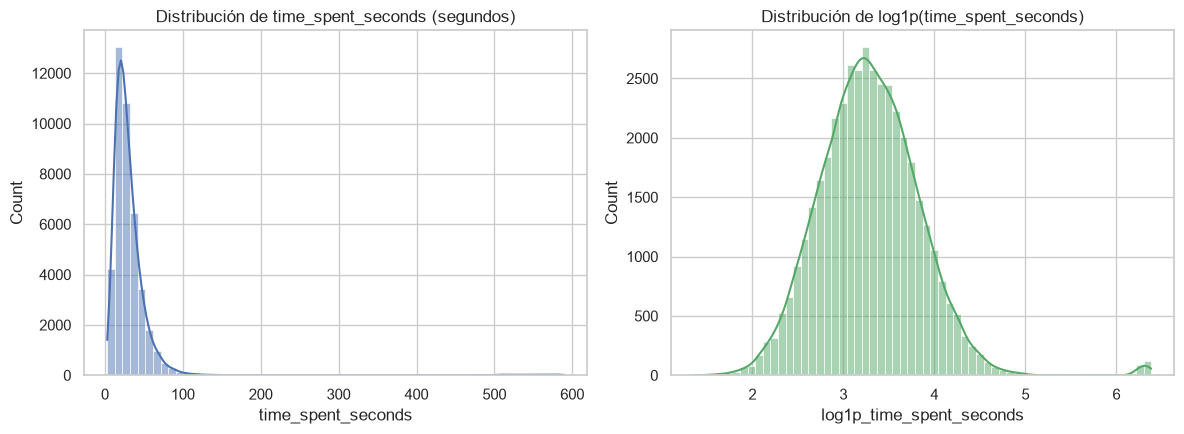

In [3]:
print("Estadísticas univariadas de time_spent_seconds:")
print(train_df["time_spent_seconds"].describe())
print()
print("Estadísticas de log1p_time_spent_seconds:")
print(train_df["log1p_time_spent_seconds"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(train_df["time_spent_seconds"], bins=60, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de time_spent_seconds (segundos)")
sns.histplot(train_df["log1p_time_spent_seconds"], bins=60, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribución de log1p(time_spent_seconds)")
plt.tight_layout()
plt.show()


**Qué se observa:** la distribución de `time_spent_seconds` está fuertemente sesgada a la
derecha (cola larga de intentos muy lentos), mientras que `log1p_time_spent_seconds` luce
mucho más simétrica y cercana a una campana.

**Qué significa:** la mayoría de los intentos se resuelven en tiempos cortos/medios, pero
existe una minoría de intentos con tiempos muy altos que "estiran" la escala original.

**Posible causa:** ejercicios de mayor dificultad, mala conectividad, distracciones del
estudiante o simplemente la naturaleza multiplicativa del tiempo de respuesta humano
(los tiempos rara vez son negativos y tienden a escalar multiplicativamente, no aditivamente).

**Cómo afecta el modelado:** entrenar un regresor directamente sobre `time_spent_seconds`
haría que los errores absolutos en los pocos valores extremos dominen la función de pérdida
(MSE), sesgando el modelo hacia esos casos raros y penalizando su desempeño en el caso típico.

**Decisión técnica:** se entrena el modelo sobre `log1p_time_spent_seconds` (ya provisto por
la ETL) y se invierte la transformación con `np.expm1()` al momento de evaluar y reportar
métricas, de modo que los errores se midan en la escala original (segundos) pero el
aprendizaje ocurra en una escala más estable.


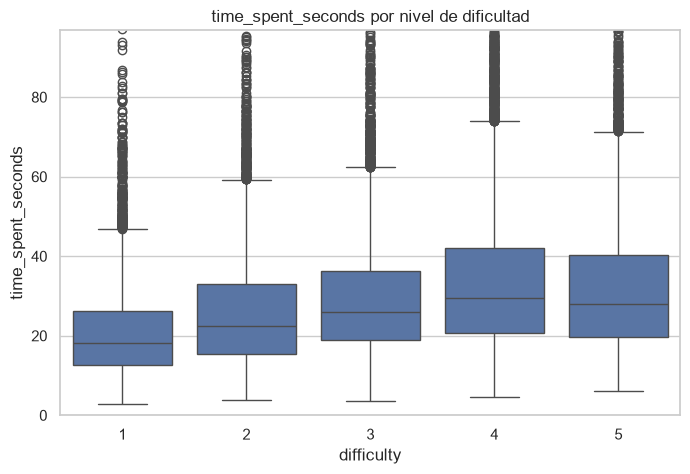

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x="difficulty", y="time_spent_seconds", color="#4C72B0")
plt.title("time_spent_seconds por nivel de dificultad")
plt.ylim(0, train_df["time_spent_seconds"].quantile(0.99))
plt.show()


**Qué se observa:** a mayor `difficulty`, la mediana y el rango intercuartílico de
`time_spent_seconds` tienden a crecer.

**Qué significa:** los ejercicios más difíciles efectivamente demandan más tiempo de
resolución, en línea con la intuición pedagógica.

**Posible causa:** ejercicios difíciles requieren más pasos de razonamiento, más lectura o
más intentos de exploración antes de responder.

**Cómo afecta el modelado:** `difficulty` es una señal predictiva relevante y monotónica
respecto al target.

**Decisión técnica:** se incluye `difficulty` como *feature* numérica (ordinal) del modelo,
sin necesidad de one-hot encoding dado su carácter ordinal.


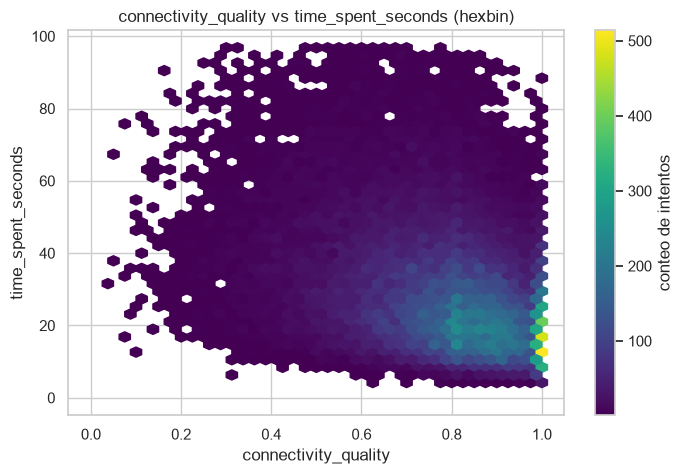

In [5]:
plt.figure(figsize=(8, 5))
plt.hexbin(train_df["connectivity_quality"], train_df["time_spent_seconds"],
           gridsize=40, cmap="viridis", mincnt=1,
           extent=(0, 1, 0, train_df["time_spent_seconds"].quantile(0.99)))
plt.colorbar(label="conteo de intentos")
plt.xlabel("connectivity_quality")
plt.ylabel("time_spent_seconds")
plt.title("connectivity_quality vs time_spent_seconds (hexbin)")
plt.show()


**Qué se observa:** la nube de puntos se concentra más densamente en tiempos bajos para
`connectivity_quality` alta, y se dispersa hacia tiempos más altos cuando la conectividad es
baja.

**Qué significa:** una conectividad pobre está asociada a mayores tiempos de respuesta
registrados (posiblemente por latencia de carga/envío, no solo por tiempo cognitivo puro).

**Posible causa:** con mala conectividad, el cliente puede tardar más en cargar el
ejercicio o en confirmar la respuesta, inflando el tiempo medido de extremo a extremo.

**Cómo afecta el modelado:** `connectivity_quality` aporta información no redundante con
`difficulty`, útil para explicar parte de la varianza del tiempo de respuesta.

**Decisión técnica:** se conserva `connectivity_quality` como feature numérica continua,
sin discretizar, para no perder la relación gradual observada.


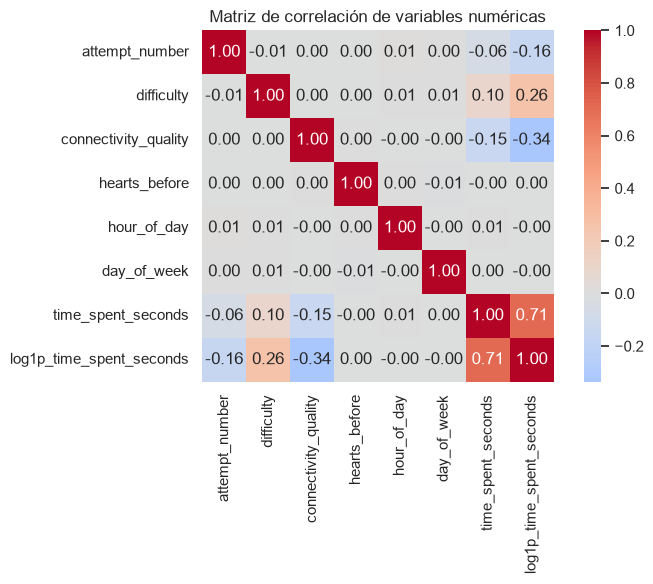

In [6]:
numeric_cols = ["attempt_number", "difficulty", "connectivity_quality", "hearts_before",
                "hour_of_day", "day_of_week", "time_spent_seconds", "log1p_time_spent_seconds"]
corr = train_df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()


**Qué se observa:** `difficulty` y `connectivity_quality` muestran las correlaciones más
notorias con `time_spent_seconds` / `log1p_time_spent_seconds`; el resto de variables
numéricas presenta correlaciones débiles entre sí (poca multicolinealidad).

**Qué significa:** no hay redundancia fuerte entre predictoras, por lo que aportan
información relativamente independiente.

**Posible causa:** cada variable captura un aspecto distinto del intento (progreso del
usuario, condiciones técnicas, contexto temporal), por diseño del simulador.

**Cómo afecta el modelado:** al no existir multicolinealidad severa, no es necesario
eliminar variables numéricas por redundancia.

**Decisión técnica:** se conservan todas las variables numéricas propuestas como features,
y se delega a modelos de ensamble de árboles (Random Forest / Gradient Boosting) la tarea de
capturar interacciones no lineales entre ellas.


## Modelado

**Target:** `time_spent_seconds`, entrenado en escala `log1p_time_spent_seconds` e invertido
con `np.expm1()` al evaluar.

**Features:** `attempt_number`, `difficulty`, `connectivity_quality`, `device_type`
(categórica), `hour_of_day`, `day_of_week`, `is_correct`, `hearts_before`.

Se compara un `RandomForestRegressor` contra un `GradientBoostingRegressor`, cada uno con una
pequeña búsqueda de hiperparámetros vía `GridSearchCV` (3-fold, sobre el conjunto de
entrenamiento únicamente).


In [7]:
FEATURES = ["attempt_number", "difficulty", "connectivity_quality", "device_type",
            "hour_of_day", "day_of_week", "is_correct", "hearts_before"]
CATEGORICAL = ["device_type"]
NUMERIC = [c for c in FEATURES if c not in CATEGORICAL]
TARGET_LOG = "log1p_time_spent_seconds"
TARGET_RAW = "time_spent_seconds"

def make_xy(df):
    X = df[FEATURES].copy()
    X["is_correct"] = X["is_correct"].astype(int)
    y_log = df[TARGET_LOG].values
    y_raw = df[TARGET_RAW].values
    return X, y_log, y_raw

X_train, y_train_log, y_train_raw = make_xy(train_df)
X_val, y_val_log, y_val_raw = make_xy(val_df)
X_test, y_test_log, y_test_raw = make_xy(test_df)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ("num", StandardScaler(), NUMERIC),
    ]
)
print("X_train shape:", X_train.shape)
X_train.head()


X_train shape: (42000, 8)


,attempt_number,difficulty,connectivity_quality,device_type,hour_of_day,day_of_week,is_correct,hearts_before
0,1,4,0.800,desktop,14,1,1,5
1,1,4,0.515,mobile,0,2,1,3
2,1,4,0.847,mobile,9,2,1,4
3,2,1,0.975,mobile,12,4,1,3
4,1,4,0.889,tablet,3,0,1,2


In [8]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

rf_param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [8, None],
}

rf_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=3,
                          scoring="neg_mean_absolute_error", n_jobs=-1)
rf_search.fit(X_train, y_train_log)

print("Mejor combinación RandomForest:", rf_search.best_params_)
print("Mejor score CV (neg MAE, escala log):", rf_search.best_score_)


Mejor combinación RandomForest: {'regressor__max_depth': 8, 'regressor__n_estimators': 200}
Mejor score CV (neg MAE, escala log): -0.37081168128534586


In [9]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42)),
])

gb_param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__learning_rate": [0.05, 0.1],
}

gb_search = GridSearchCV(gb_pipeline, gb_param_grid, cv=3,
                          scoring="neg_mean_absolute_error", n_jobs=-1)
gb_search.fit(X_train, y_train_log)

print("Mejor combinación GradientBoosting:", gb_search.best_params_)
print("Mejor score CV (neg MAE, escala log):", gb_search.best_score_)


Mejor combinación GradientBoosting: {'regressor__learning_rate': 0.05, 'regressor__n_estimators': 200}
Mejor score CV (neg MAE, escala log): -0.36823281025912796


In [10]:
def evaluate_in_seconds(model, X, y_true_raw):
    y_pred_log = model.predict(X)
    y_pred_raw = np.expm1(y_pred_log)
    y_pred_raw = np.clip(y_pred_raw, 0, None)
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    mse = mean_squared_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_raw, y_pred_raw)
    return {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2}

candidates = {
    "RandomForestRegressor": rf_search.best_estimator_,
    "GradientBoostingRegressor": gb_search.best_estimator_,
}

val_results = {name: evaluate_in_seconds(model, X_val, y_val_raw) for name, model in candidates.items()}
val_results_df = pd.DataFrame(val_results).T
print("Métricas en validación (segundos, tras invertir log1p):")
val_results_df


Métricas en validación (segundos, tras invertir log1p):


,mae,mse,rmse,r2
RandomForestRegressor,13.051961,1589.167103,39.864359,0.023855
GradientBoostingRegressor,13.010697,1587.722807,39.846240,0.024742


Se elige el modelo con menor MAE en el conjunto de validación (métrica interpretable
directamente en segundos, robusta a outliers residuales). El resultado exacto de la
comparación se observa en la tabla de la celda anterior; a continuación se selecciona
automáticamente el ganador según ese criterio.


In [11]:
best_name = val_results_df["mae"].idxmin()
best_model = candidates[best_name]
print("Modelo ganador:", best_name)
print(val_results_df.loc[best_name])


Modelo ganador: GradientBoostingRegressor
mae       13.010697
mse     1587.722807
rmse      39.846240
r2         0.024742
Name: GradientBoostingRegressor, dtype: float64


In [12]:
test_metrics = evaluate_in_seconds(best_model, X_test, y_test_raw)
print(f"Métricas finales de {best_name} en el conjunto de TEST (segundos):")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")


Métricas finales de GradientBoostingRegressor en el conjunto de TEST (segundos):
  mae: 13.3945
  mse: 1836.0036
  rmse: 42.8486
  r2: 0.0176


In [13]:
MODEL_PATH = MODELS_DIR / "time_estimator.joblib"
joblib.dump({"pipeline": best_model}, MODEL_PATH)

val_metrics = val_results[best_name]

metadata = {
    "model_name": "time_estimator",
    "version": "1.0.0",
    "algorithm": best_name,
    "task": "regression",
    "target": "time_spent_seconds",
    "target_transform": "log1p",
    "features": FEATURES,
    "categorical_features": CATEGORICAL,
    "metrics": {
        "validation": {"mae": val_metrics["mae"], "rmse": val_metrics["rmse"], "r2": val_metrics["r2"]},
        "test": {"mae": test_metrics["mae"], "rmse": test_metrics["rmse"], "r2": test_metrics["r2"]},
    },
    "trained_at": datetime.now().isoformat(),
    "notes": (
        f"Se compararon RandomForestRegressor y GradientBoostingRegressor con busqueda de "
        f"hiperparametros via GridSearchCV (3-fold) sobre el set de entrenamiento, entrenando "
        f"sobre log1p(time_spent_seconds) e invirtiendo con expm1 para evaluar en segundos. "
        f"Se eligio {best_name} por tener el menor MAE en validacion "
        f"({val_metrics['mae']:.3f}s vs el otro candidato)."
    ),
}

META_PATH = MODELS_DIR / "time_estimator_metadata.json"
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Guardado modelo en:", MODEL_PATH)
print("Guardado metadata en:", META_PATH)
print(json.dumps(metadata, indent=2, ensure_ascii=False))


Guardado modelo en: C:\Users\tass1\Videos\tutunakun\tutunakun\models\serialized\time_estimator.joblib
Guardado metadata en: C:\Users\tass1\Videos\tutunakun\tutunakun\models\serialized\time_estimator_metadata.json
{
  "model_name": "time_estimator",
  "version": "1.0.0",
  "algorithm": "GradientBoostingRegressor",
  "task": "regression",
  "target": "time_spent_seconds",
  "target_transform": "log1p",
  "features": [
    "attempt_number",
    "difficulty",
    "connectivity_quality",
    "device_type",
    "hour_of_day",
    "day_of_week",
    "is_correct",
    "hearts_before"
  ],
  "categorical_features": [
    "device_type"
  ],
  "metrics": {
    "validation": {
      "mae": 13.01069710647602,
      "rmse": 39.84623955860209,
      "r2": 0.024741963633359565
    },
    "test": {
      "mae": 13.394510010871075,
      "rmse": 42.848613050777374,
      "r2": 0.017592348057280827
    }
  },
  "trained_at": "2026-07-31T18:32:39.760606",
  "notes": "Se compararon RandomForestRegressor y 

## Verificación del artefacto exportado

Se recarga el pipeline serializado desde disco (simulando un proceso de inferencia
independiente, como el que usaría la futura API) y se predice sobre 3 filas de la muestra de
inferencia, sin usar ninguna variable en memoria de las celdas anteriores más que las rutas.


In [14]:
fresh = joblib.load(MODEL_PATH)
fresh_pipeline = fresh["pipeline"]

inference_df = pd.read_csv(DATA_DIR / "inference" / "exercise_attempts_inference_sample.csv")
sample = inference_df.sample(n=3, random_state=7).copy()

X_sample = sample[FEATURES].copy()
X_sample["is_correct"] = X_sample["is_correct"].astype(int)

pred_log = fresh_pipeline.predict(X_sample)
pred_seconds = np.clip(np.expm1(pred_log), 0, None)

result = sample[["attempt_id", "user_id", "time_spent_seconds"]].copy()
result["predicted_time_spent_seconds"] = pred_seconds
print(result.to_string(index=False))


 attempt_id  user_id  time_spent_seconds  predicted_time_spent_seconds
      55270      201           13.900000                     25.941773
      33217      269          552.189425                     29.106723
       7275      376           51.200000                     27.504214
